<a href="https://colab.research.google.com/github/Carpio1210/Fundamentos-de-Programaci-n/blob/main/Actividad_AULA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Te damos la bienvenida a Colab

## Descubre la API de Gemini
La API de Gemini te da acceso a los modelos de Gemini creados por Google DeepMind. Los modelos de Gemini se han diseñado desde cero para ser multimodales, por lo que puedes razonar sin problemas a partir de texto, imágenes, código y audio.

**Cómo empezar**
*  Ve a <a href="https://aistudio.google.com/">Google AI Studio</a> e inicia sesión con tu cuenta de Google.
*  <a href="https://aistudio.google.com/app/apikey">Crea una clave de API</a>.
* Usa una guía de inicio rápido para <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb">Python</a> o llama a la API REST con <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb">curl</a>.

**Descubre las funciones avanzadas de Gemini**
*  Juega con los <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb">resultados multimodales</a> de Gemini, mezclando texto e imágenes de forma iterativa.
*  Descubre la <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb">API Live multimodal</a> &#40;<a href="https://aistudio.google.com/live">demo</a>&#41;.
*  Descubre cómo <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb&quot;">analizar imágenes y detectar elementos en tus fotos</a> con Gemini &#40;también hay una <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb">versión en 3D</a>&#41;.
*  Accede al potencial del <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb">modelo de pensamiento de Gemini</a>, capaz de resolver tareas complejas con sus pensamientos internos.
      
**Descubre casos prácticos complejos**
*  Usa las <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb">funciones básicas de Gemini</a> para crear un informe sobre una empresa basado en lo que el modelo puede encontrar en Internet.
*  Extrae <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb">datos de facturas y formularios a partir de PDFs</a> de forma estructurada.
*  Crea <a href="https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb">ilustraciones basadas en un libro completo</a> con la ventana de contexto grande de Gemini e Imagen.

Para obtener más información, consulta la <a href="https://github.com/google-gemini/cookbook">guía paso a paso de Gemini</a> o visita la <a href="https://ai.google.dev/docs/">documentación de la API de Gemini</a>.


In [61]:
import pandas as pd
from google.colab import files

files.upload()

df = pd.read_csv('alfonsowatts (1).csv')

Saving alfonsowatts.csv to alfonsowatts (4).csv


In [62]:
el_dataset_1 = df.sample(100)
X = df[['chips_per_min','temperature']]
y = df['alfonsowatts']
print( el_dataset_1)

       Unnamed: 0  chips_per_min  temperature  alfonsowatts
8806         8806       1.491400     1.560271     15.842377
18103       18103       2.520711     3.072808     29.610978
488           488       2.161950     2.982759     23.486758
6568         6568       2.674680     3.693613     25.765661
2937         2937       2.497920     2.830581     27.806670
...           ...            ...          ...           ...
11168       11168       1.227309     0.913541     18.810102
7135         7135       2.326784     1.089273     13.033812
11479       11479       2.832468     1.822163     24.515086
794           794       1.445688     3.969013     16.080630
14361       14361       2.395208     1.820197     28.448609

[100 rows x 4 columns]


Ahora, Colab incluye funciones de IA basadas en <a href="https://gemini.google.com">Gemini</a>. En el vídeo de abajo se proporciona información sobre cómo usar estas funciones, ya seas nuevo en Python o tengas experiencia.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  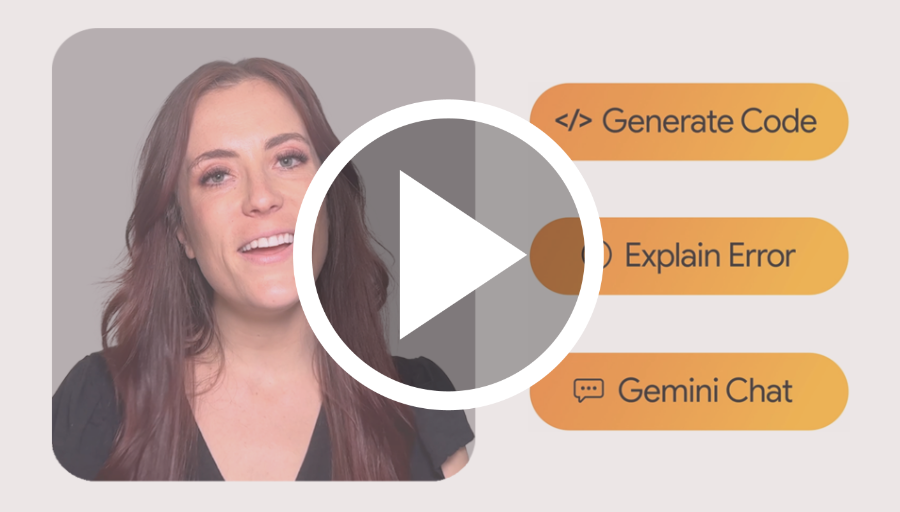
  </a>
</center>

In [63]:
import numpy as np

n = X.shape[0]
X = np.column_stack((X, np.ones(n)))

In [64]:
print(X.shape)
print(np.linalg.det(X.T @ X))

(25000, 3)
5316207459773.061


In [65]:
XT = X.T #Transpuesta
A = XT @ X    #Multiplicacion de transpuesta por matriz
A_inv = np.linalg.inv(A) #Modulo de algebra lineal para calcular la inversa
B = A_inv @ XT #La algebra lineal por la transpuesta
w = B @ y #Multiplicacion de la transpuesta por la inversa de la transpuesta por la original por las filas

print(w)

[4.4374669  1.77973339 8.20112509]


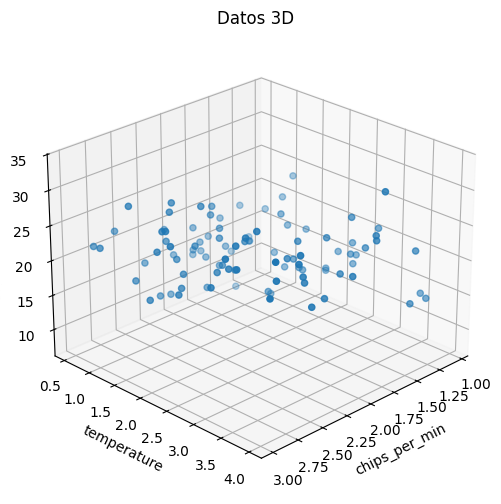

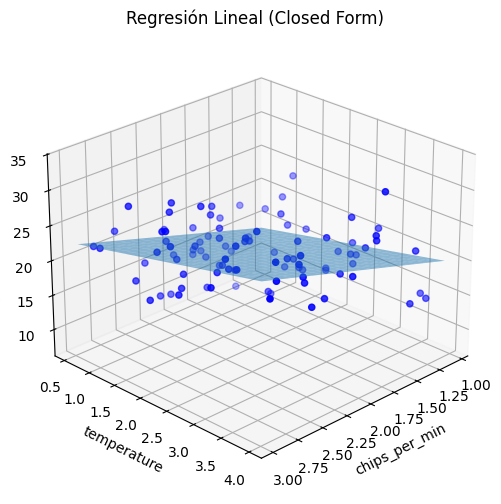

In [66]:
X = el_dataset_1[['chips_per_min','temperature']].values
y = el_dataset_1['alfonsowatts'].values

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# usar SOLO las 2 features (sin el 1)
X_plot = X[:, :2]

ax.scatter(X_plot[:,0], X_plot[:,1], y)

ax.set_xlabel("chips_per_min")
ax.set_ylabel("temperature")
ax.set_zlabel("alfonsowatts")

# ajustar ángulo para que se vea mejor
ax.view_init(elev=25, azim=45)

plt.title("Datos 3D")
plt.show()

# crear grid
x_surf, y_surf = np.meshgrid(
    np.linspace(X_plot[:,0].min(), X_plot[:,0].max(), 20),
    np.linspace(X_plot[:,1].min(), X_plot[:,1].max(), 20)
)

# ecuación del plano
z_surf = w[0]*x_surf + w[1]*y_surf + w[2]

# graficar
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# puntos
ax.scatter(X_plot[:,0], X_plot[:,1], y, color='blue')

# plano
ax.plot_surface(x_surf, y_surf, z_surf, alpha=0.5)

ax.set_xlabel("chips_per_min")
ax.set_ylabel("temperature")
ax.set_zlabel("alfonsowatts")

ax.view_init(elev=25, azim=45)

plt.title("Regresión Lineal (Closed Form)")
plt.show()

In [26]:
#¿Por qué se sigue la dirección opuesta (negativa) al gradiente?
#Por que el gradiente te lleva a donde la función sube, y nosotros queremos encontrar el minimo, por eso se sigue la dirección opuesta.

#¿Cómo esa dirección define que α > 0?
#Por que el signo negativo ya indica la dirección, entonces α tiene que ser positiva

#¿A dónde conchas se fue el 2? Porque lo que hemos hecho está bien.
#Se combina con la variable Alpha.


Iteración 0 → Loss: 45846.64256657224
Iteración 500 → Loss: 41609.57938962469
Iteración 1000 → Loss: 37776.17932956981
Iteración 1500 → Loss: 34307.983819592686
Iteración 2000 → Loss: 31170.19856587702
Iteración 2500 → Loss: 28331.344404007486
Iteración 3000 → Loss: 25762.941424601424
Iteración 3500 → Loss: 23439.223197838706
Iteración 4000 → Loss: 21336.87822868526
Iteración 4500 → Loss: 19434.816047941218
Iteración 5000 → Loss: 17713.955591527527
Iteración 5500 → Loss: 16157.03374414293
Iteración 6000 → Loss: 14748.43212582001
Iteración 6500 → Loss: 13474.02038301613
Iteración 7000 → Loss: 12321.014411533337
Iteración 7500 → Loss: 11277.848088431243
Iteración 8000 → Loss: 10334.057225684059
Iteración 8500 → Loss: 9480.174581000356
Iteración 9000 → Loss: 8707.634872199269
Iteración 9500 → Loss: 8008.688841938055

===== RESULTADOS =====
w Gradient: [13.17052389  1.58241457  1.35081898]
w Closed Form: [20.83485571  2.44976419  2.07318066]
Loss Gradient: 7377.528108211968
Loss Closed For

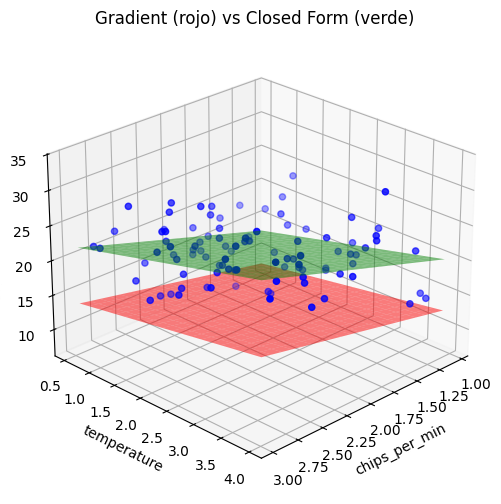

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =========================
# 🔹 DATOS ORIGINALES
# =========================
X_raw = el_dataset_1[['chips_per_min','temperature']].values
y = el_dataset_1['alfonsowatts'].values

# =========================
# 🔹 NORMALIZAR X (IMPORTANTE)
# =========================
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)

X_norm = (X_raw - X_mean) / X_std

# =========================
# 🔹 AGREGAR BIAS
# =========================
X = np.c_[np.ones(len(X_norm)), X_norm]

# =========================
# 🔹 GRADIENT DESCENT + STOPPING
# =========================
w = np.zeros(X.shape[1])
alpha = 0.01
epsilon = 1e-6
prev_loss = float('inf')

for i in range(10000):

    # gradiente correcto (promedio)
    grad = (1/100) *(1/len(X)) * X.T @ (X @ w - y)
    w = w - alpha * grad

    loss = np.linalg.norm(X @ w - y)**2

    if i % 500 == 0:
        print(f"Iteración {i} → Loss: {loss}")

    if abs(prev_loss - loss) < epsilon:
        print("===================================")
        print("STOPPING CONDITION ACTIVADA ✅")
        print(f"Iteración final: {i}")
        print(f"Cambio en loss: {abs(prev_loss - loss)}")
        print("===================================")
        break

    prev_loss = loss

# =========================
# 🔹 CLOSED FORM
# =========================
w_closed = np.linalg.pinv(X.T @ X) @ X.T @ y

# =========================
# 🔹 LOSSES
# =========================
loss_gd = np.linalg.norm(X @ w - y)**2
loss_cf = np.linalg.norm(X @ w_closed - y)**2

print("\n===== RESULTADOS =====")
print("w Gradient:", w)
print("w Closed Form:", w_closed)
print("Loss Gradient:", loss_gd)
print("Loss Closed Form:", loss_cf)

# =========================
# 🔹 GRÁFICA 3D
# =========================
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# 🔵 puntos (usar datos originales)
ax.scatter(X_raw[:,0], X_raw[:,1], y, color='blue')

# grid
x_vals = np.linspace(X_raw[:,0].min(), X_raw[:,0].max(), 20)
y_vals = np.linspace(X_raw[:,1].min(), X_raw[:,1].max(), 20)
x_vals, y_vals = np.meshgrid(x_vals, y_vals)

# 🔴 IMPORTANTE: normalizar grid igual que X
x_norm = (x_vals - X_mean[0]) / X_std[0]
y_norm = (y_vals - X_mean[1]) / X_std[1]

# planos
z_gd = w[0] + w[1]*x_norm + w[2]*y_norm
z_cf = w_closed[0] + w_closed[1]*x_norm + w_closed[2]*y_norm

# planos
ax.plot_surface(x_vals, y_vals, z_gd, alpha=0.5, color='red')
ax.plot_surface(x_vals, y_vals, z_cf, alpha=0.5, color='green')

# etiquetas
ax.set_xlabel("chips_per_min")
ax.set_ylabel("temperature")
ax.set_zlabel("alfonsowatts")

ax.view_init(elev=25, azim=45)

plt.title("Gradient (rojo) vs Closed Form (verde)")
plt.show()

In [ ]:
#¿Cuál es el orden (Big O notation) del programa que utiliza la closed form para encontrar el plano de best fit?
#Partimos de: w = (D^T * D)^−1 * D^T * y

#Calculamos D^T  ----> d x n

#Multiplicamos (d X n) (n X d)

#O(nd^2), luego invertimos la matriz (D^T * D)^-1, esa matriz es de tamano d x d.
#O(d^3)

#(d x d) (d x n) -> O(d^2 * n)
#(d x n) (n x 1) -> O(nd)

#Entonces sumamos todo: O(nd^2 + d^3)

#si d crece mucho → la inversa domina
#si n crece mucho → la multiplicación domina

#D^T(Dw - y) --> Gradient descent, en cada iteración se calcula el gradiente:

#O(Tnd) --> Complejidad total.

#¿Y del programa que utiliza descenso por gradiente durante T iteraciones?

#El número de iteraciones 𝑇 puede definirse como un valor máximo de iteraciones, pero no es la mejor forma de controlar el entrenamiento, ya que:

#Si 𝑇 es muy pequeño, el algoritmo puede no converger
#Si 𝑇 es muy grande, puede desperdiciar tiempo computacional

#Por ello, es mejor utilizar una condición de parada (stopping condition) basada en el cambio de la función de pérdida:

<div class="markdown-google-sans">
  <h2>¿Qué es Colaboratory?</h2>
</div>

Colab, también conocido como "Colaboratory", te permite programar y ejecutar Python en tu navegador con las siguientes ventajas:
- No requiere configuración
- Acceso a GPUs sin coste adicional
- Permite compartir contenido fácilmente

Colaboratory puede facilitar tu trabajo, ya seas <strong>alumno</strong>, <strong>científico de datos</strong> o <strong>investigador de IA</strong>. No te pierdas <a href="https://www.youtube.com/watch?v=inN8seMm7UI">Introduction to Colab</a> o <a href="https://www.youtube.com/watch?v=rNgswRZ2C1Y">Colab Features You May Have Missed</a> para obtener más información. O bien, ¡empieza a continuación!

<div class="markdown-google-sans">

## <strong>Primeros pasos</strong>
</div>

El documento que estás leyendo no es una página web estática, sino un entorno interactivo denominado <strong>cuaderno de Colab</strong> que te permite escribir y ejecutar código.

Por ejemplo, a continuación se muestra una <strong>celda de código</strong> con una breve secuencia de comandos de Python que calcula un valor, lo almacena en una variable e imprime el resultado:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

Si quieres ejecutar el código de la celda anterior, haz clic para seleccionarlo y pulsa el botón de reproducir situado a la izquierda del código o usa la combinación de teclas "Comando/Ctrl + Intro". Para editar el código, solo tienes que hacer clic en la celda.

Las variables que definas en una celda se pueden usar después en otras celdas:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Los cuadernos de Colab te permiten combinar <strong>código ejecutable</strong> y <strong>texto enriquecido</strong> en un mismo documento, además de <strong>imágenes</strong>, <strong>HTML</strong>, <strong>LaTeX</strong> y mucho más. Los cuadernos que creas en Colab se almacenan en tu cuenta de Google Drive. Puedes compartir tus cuadernos de Colab fácilmente con compañeros de trabajo o amigos, lo que les permite comentarlos o incluso editarlos. Consulta más información en <a href="/notebooks/basic_features_overview.ipynb">Información general sobre Colab</a>. Para crear un cuaderno de Colab, puedes usar el menú Archivo que aparece arriba o bien acceder al enlace para <a href="http://colab.research.google.com#create=true">crear un cuaderno de Colab</a>.

Los cuadernos de Colab son cuadernos de Jupyter alojados en Colab. Para obtener más información sobre el proyecto Jupyter, visita <a href="https://www.jupyter.org">jupyter.org</a>.

<div class="markdown-google-sans">

## Ciencia de datos
</div>

Con Colab, puedes aprovechar toda la potencia de las bibliotecas más populares de Python para analizar y visualizar datos. La celda de código de abajo utiliza <strong>NumPy</strong> para generar datos aleatorios y <strong>Matplotlib</strong> para visualizarlos. Para editar el código, solo tienes que hacer clic en la celda.

Puedes importar tus propios datos a los cuadernos de Colab desde tu cuenta de Google Drive, incluidas las hojas de cálculo, y también desde GitHub y muchas fuentes más. Para obtener más información sobre cómo importar datos y cómo se puede usar Colab en la ciencia de datos, consulta los enlaces que aparecen en la sección <a href="#working-with-data">Trabajar con datos</a> más abajo.

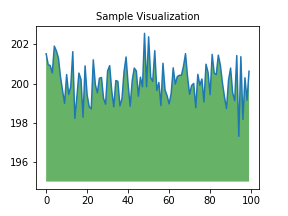

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Los cuadernos de Colab ejecutan código en los servidores en la nube de Google, lo que te permite aprovechar la potencia del hardware de Google, incluidas las <a href="#using-accelerated-hardware">GPUs y TPUs</a>, independientemente de la potencia de tu equipo. Lo único que necesitas es un navegador.

Por ejemplo, si estás esperando a que termine de ejecutarse el código de <strong>pandas</strong> y quieres que sea más rápido, puedes cambiar a un entorno de ejecución con GPU y usar bibliotecas como <a href="https://rapids.ai/cudf-pandas">RAPIDS cuDF</a>, que proporcionan aceleración sin cambios en el código.

Para obtener más información sobre cómo acelerar pandas en Colab, consulta la <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb">guía de 10 minutos</a> o la <a href="https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb">demo de análisis de datos del mercado de valores de EE. UU.</a>

<div class="markdown-google-sans">

## Aprendizaje automático
</div>

Con Colab, puedes importar un conjunto de datos de imágenes, entrenar un clasificador de imágenes con dicho conjunto de datos y evaluar el modelo con tan solo usar unas <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">pocas líneas de código</a>.

Colab es una herramienta muy utilizada en la comunidad de aprendizaje automático. Estos son algunos ejemplos de las aplicaciones que tiene Colab:
- Dar los primeros pasos con TensorFlow
- Desarrollar y entrenar redes neuronales
- Experimentar con TPUs
- Divulgar datos de investigación sobre IA
- Crear tutoriales

Para ver cuadernos de Colab que demuestran las aplicaciones del aprendizaje automático, consulta los <a href="#machine-learning-examples">ejemplos de aprendizaje automático</a> de abajo.

<div class="markdown-google-sans">

## Más recursos

### Trabajar con cuadernos en Colab

</div>

- [Introducción a Colab](/notebooks/basic_features_overview.ipynb)
- [Guía de Markdown](/notebooks/markdown_guide.ipynb)
- [Importar bibliotecas e instalar dependencias](/notebooks/snippets/importing_libraries.ipynb)
- [Guardar y cargar cuadernos en GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Formularios interactivos](/notebooks/forms.ipynb)
- [Widgets interactivos](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Trabajar con datos
</div>

- [Cargar datos: Drive, Hojas de cálculo y Google Cloud Storage](/notebooks/io.ipynb)
- [Gráficos: visualización de datos](/notebooks/charts.ipynb)
- [Primeros pasos con BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Aprendizaje automático

<div>

A continuación, se muestran algunos cuadernos relacionados con el aprendizaje automático, incluido el curso online de Google sobre aprendizaje automático. Para obtener más información, consulta el <a href="https://developers.google.com/machine-learning/crash-course/">sitio web del curso</a>.
- [Introducción a Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Introducción a RAPIDS cuDF para acelerar Pandas](https://nvda.ws/rapids-cudf)
- [Primeros pasos con el modo de acelerador de cuML](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)
- [Regresión lineal con tf.keras usando datos sintéticos](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/linear_regression_with_synthetic_data.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Uso de hardware acelerado
</div>

- [TensorFlow con GPUs](/notebooks/gpu.ipynb)
- [TPUs en Colab](/notebooks/tpu.ipynb)

# Nueva sección

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("https://raw.githubusercontent.com/evareladev/nn-course-resources/refs/heads/main/Simple-percetron/Product_profitability_dataset.csv")

df.head()

X = df.drop(columns =['profitable'])
Y = df['profitable']

print(Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

scaler = StardardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

0        0
1        1
2        1
3        1
4        0
        ..
34995    0
34996    0
34997    0
34998    1
34999    1
Name: profitable, Length: 35000, dtype: int64
(35000, 3) (28000, 3) (7000, 3)


<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Ejemplos destacados

</div>

- <a href="https://tensorflow.org/hub/tutorials/tf2_image_retraining">Reentrenamiento de un clasificador de imágenes</a>: crea un modelo de Keras sobre un clasificador de imágenes preparado previamente para que distinga flores.
- <a href="https://tensorflow.org/hub/tutorials/tf2_text_classification">Clasificación de textos</a>: clasifica las reseñas de películas de IMDb en <em>positivas</em> o <em>negativas</em>.
- <a href="https://tensorflow.org/hub/tutorials/tf2_arbitrary_image_stylization">Transferencia de estilo</a>: utiliza el aprendizaje profundo para transferir el estilo de una imagen a otra.
- <a href="https://tensorflow.org/hub/tutorials/retrieval_with_tf_hub_universal_encoder_qa">Codificador universal de frases multilingüe para preguntas y respuestas</a>: utiliza un modelo de aprendizaje automático para contestar preguntas con el conjunto de datos SQuAD.
- <a href="https://tensorflow.org/hub/tutorials/tweening_conv3d">Interpolación de vídeo</a>: predice lo que ocurre entre el primer y el último fotograma de un vídeo.


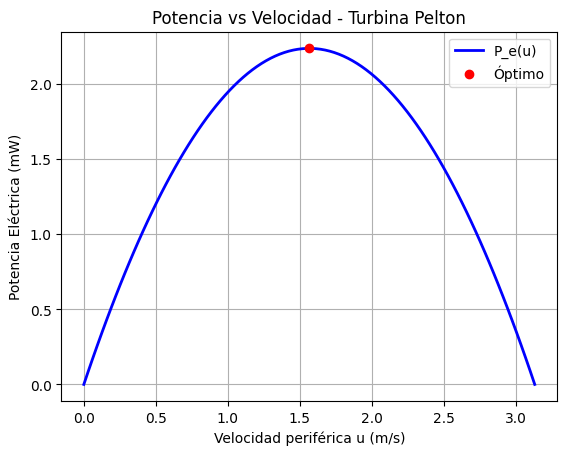

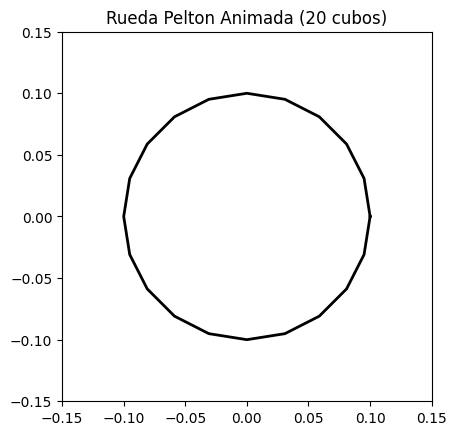

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Parámetros
rho, g, Q, h, D = 1000, 9.81, 5e-5, 0.5, 0.2
Vj = np.sqrt(2 * g * h)
u_opt = Vj / 2
theta = 165 * np.pi / 180  # rad
eta_h, eta_m, eta_g = 0.85, 0.9, 0.7
Z = 20  # Cubos

# Vector u
u = np.linspace(0, Vj, 100)

# Potencia
deltaV = (Vj - u) * (1 + np.cos(theta))
P_h = rho * Q * deltaV * u  # W
P_useful = P_h * eta_h
P_mec = P_useful * eta_m
P_e = P_mec * eta_g

# Plot potencia
plt.figure(1)
plt.plot(u, P_e * 1000, 'b-', linewidth=2)
plt.plot(u_opt, np.max(P_e)*1000, 'ro')
plt.xlabel('Velocidad periférica u (m/s)')
plt.ylabel('Potencia Eléctrica (mW)')
plt.title('Potencia vs Velocidad - Turbina Pelton')
plt.legend(['P_e(u)', 'Óptimo'])
plt.grid(True)
plt.show()

# Vista rueda + animación simple
fig, ax = plt.subplots()
ax.set_xlim(-0.15, 0.15)
ax.set_ylim(-0.15, 0.15)
ax.set_aspect('equal')
ax.set_title('Rueda Pelton Animada (20 cubos)')

# Rueda inicial
theta_wheel = np.linspace(0, 2*np.pi, Z+1)
line, = ax.plot(D/2 * np.cos(theta_wheel), D/2 * np.sin(theta_wheel), 'k-', linewidth=2)

def animate(frame):
    ax.clear()
    ax.set_xlim(-0.15, 0.15)
    ax.set_ylim(-0.15, 0.15)
    ax.set_aspect('equal')
    # Rotación
    rot = frame * 2 * np.pi / 100  # 100 frames por vuelta
    theta_rot = theta_wheel + rot
    ax.plot(D/2 * np.cos(theta_rot), D/2 * np.sin(theta_rot), 'k-', linewidth=2)
    # Cubos (arcos)
    for i in range(Z):
        ang = theta_rot[i]
        arc = np.linspace(ang - np.pi/12, ang + np.pi/12, 20)
        ax.plot(0.8*(D/2) * np.cos(arc), 0.8*(D/2) * np.sin(arc), 'g-')
    # Chorro fijo
    ax.plot([0, 0.08], [0.11, 0.08], 'b-', linewidth=3)
    return line,

anim = FuncAnimation(fig, animate, frames=100, interval=50, blit=False)
plt.show()  # O anim.save('rueda.gif') para GIF

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de diseño
D = 0.2  # Diámetro de la rueda (m)
g = 9.81  # Gravedad (m/s²)

# Asumiendo valores típicos de bomba de pecera
Q = 0.0001  # Caudal (m³/s) - 0.1 L/s
H = 1.5     # Altura aproximada (m)

# Velocidad del chorro
V_chorro = np.sqrt(2 * g * H)
print(f"Velocidad del chorro: {V_chorro:.2f} m/s")

# Velocidad óptima de la rueda (0.45-0.48 * V_chorro)
U_optimo = 0.47 * V_chorro
print(f"Velocidad óptima de la rueda: {U_optimo:.2f} m/s")

# RPM óptimas
RPM_optimo = (U_optimo * 60) / (np.pi * D/2)
print(f"RPM óptimos: {RPM_optimo:.0f} rpm")

# Potencia teórica máxima
rho = 1000  # Densidad del agua (kg/m³)
P_max = rho * Q * g * H
print(f"Potencia teórica máxima: {P_max*1000:.2f} W")

Velocidad del chorro: 5.42 m/s
Velocidad óptima de la rueda: 2.55 m/s
RPM óptimos: 487 rpm
Potencia teórica máxima: 1471.50 W


In [ ]:
# Cálculo del sistema de multiplicación
# Motor de ventilador de auto típico: 12V, 2000-3000 RPM a 12V

import numpy as np

# Parámetros de diseño
D = 0.2  # Diámetro de la rueda (m)

# Asumiendo valores típicos de bomba de pecera
Q = 0.0001  # Caudal (m³/s) - 0.1 L/s
H = 1.5     # Altura aproximada (m)
g = 9.81  # Gravedad (m/s²)


# Velocidad del chorro
V_chorro = np.sqrt(2 * g * H)

# Velocidad óptima de la rueda (0.45-0.48 * V_chorro)
U_optimo = 0.47 * V_chorro


# RPM óptimas
RPM_optimo = (U_optimo * 60) / (np.pi * D/2)


# Relación de multiplicación necesaria
RPM_generador = 2500  # RPM óptimas del motor como generador
relacion_multiplicacion = RPM_generador / RPM_optimo

print(f"Relación de multiplicación necesaria: {relacion_multiplicacion:.1f}:1")

# Voltaje esperado (asumiendo eficiencia)
eficiencia = 0.6  # 60% de eficiencia total
V_esperado = 12 * (RPM_optimo * relacion_multiplicacion) / 3000 * eficiencia
print(f"Voltaje esperado: {V_esperado:.2f} V")

NameError: name 'RPM_optimo' is not defined

In [ ]:
# Dimensiones de las cucharas
# Diámetro del chorro
A_chorro = Q / V_chorro
d_chorro = np.sqrt(4 * A_chorro / np.pi)

# Dimensiones recomendadas de cucharas
ancho_cuchara = 3 * d_chorro
profundidad_cuchara = 2.5 * d_chorro
altura_cuchara = 1.2 * d_chorro

print(f"Diámetro del chorro: {d_chorro*1000:.1f} mm")
print(f"Ancho de cuchara recomendado: {ancho_cuchara*1000:.1f} mm")
print(f"Profundidad de cuchara: {profundidad_cuchara*1000:.1f} mm")

Diámetro del chorro: 4.8 mm
Ancho de cuchara recomendado: 14.5 mm
Profundidad de cuchara: 12.1 mm


In [ ]:
# Diseño del multiplicador de voltaje (Cockcroft-Walton)
def disenar_multiplicador_voltaje(etapas, V_input):
    """
    Diseña un multiplicador de voltaje
    etapas: número de etapas de duplicación
    V_input: voltaje de entrada
    """
    V_output = V_input * 2 * etapas * 0.85  # 85% de eficiencia por etapa

    # Valores típicos de capacitores
    C_valor = 100 * 10**(-6)  # 100μF por etapa

    return {
        'etapas': etapas,
        'capacitores_por_etapa': 2,
        'valor_capacitores': f"{int(C_valor*10**6)}μF",
        'diodos_por_etapa': 2,
        'voltaje_salida_teorico': V_output,
        'voltaje_salida_real': V_output * 0.7  # Considerando pérdidas
    }

# Ejemplo para 3 etapas
multiplicador = disenar_multiplicador_voltaje(3, 3.0)
print(f"Voltaje de salida esperado: {multiplicador['voltaje_salida_real']:.2f} V")

Voltaje de salida esperado: 10.71 V


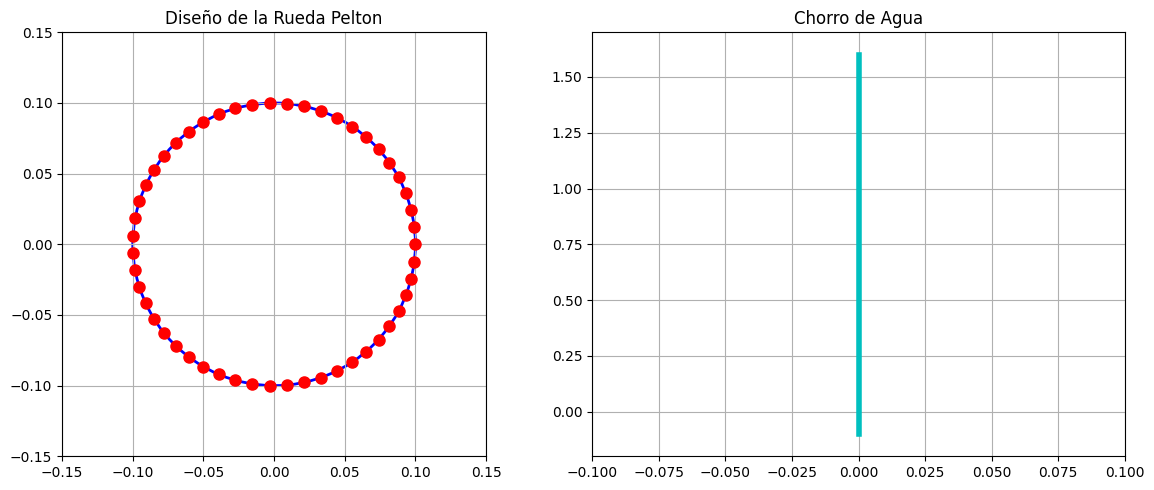

=== PARÁMETROS DE DISEÑO ===
Velocidad del chorro: 5.42 m/s
Velocidad óptima rueda: 2.55 m/s
RPM óptimos: 487 rpm
Potencia máxima: 1471.500 W
Diámetro del chorro: 4.8 mm
Número de cucharas: 51
Ángulo divisor: 165°


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

class TurbinaPelton:
    def __init__(self, diametro=0.2, caudal=0.0001, altura=1.5):
        self.D = diametro
        self.Q = caudal
        self.H = altura
        self.g = 9.81
        self.rho = 1000

    def calcular_parametros(self):
        """Calcula todos los parámetros de diseño"""
        self.V_chorro = np.sqrt(2 * self.g * self.H)
        self.U_optimo = 0.47 * self.V_chorro
        self.RPM_optimo = (self.U_optimo * 60) / (np.pi * self.D/2)
        self.P_max = self.rho * self.Q * self.g * self.H

        # Dimensiones del chorro
        self.A_chorro = self.Q / self.V_chorro
        self.d_chorro = np.sqrt(4 * self.A_chorro / np.pi)

        return {
            'velocidad_chorro': self.V_chorro,
            'velocidad_optima_rueda': self.U_optimo,
            'rpm_optimo': self.RPM_optimo,
            'potencia_maxima': self.P_max,
            'diametro_chorro': self.d_chorro
        }

    def disenar_cucharas(self):
        """Diseña las cucharas óptimas"""
        ancho = 3 * self.d_chorro
        profundidad = 2.5 * self.d_chorro
        altura_cuchara = 1.2 * self.d_chorro

        # Número óptimo de cucharas
        perimetro = np.pi * self.D
        espacio_entre_cucharas = 2.5 * self.d_chorro
        n_cucharas = int(perimetro / espacio_entre_cucharas)

        return {
            'ancho': ancho,
            'profundidad': profundidad,
            'altura': altura_cuchara,
            'numero_optimo': n_cucharas,
            'angulo_divisor': 165  # Grados óptimo para Pelton
        }

    def visualizar_diseno(self):
        """Visualiza el diseño de la turbina"""
        fig, ax = plt.subplots(1, 2, figsize=(12, 5))

        # Rueda con cucharas
        circle = Circle((0, 0), self.D/2, fill=False, edgecolor='blue', linewidth=2)
        ax[0].add_patch(circle)

        params = self.calcular_parametros()
        cucharas = self.disenar_cucharas()

        # Dibujar cucharas
        for i in range(cucharas['numero_optimo']):
            angle = 2 * np.pi * i / cucharas['numero_optimo']
            x = (self.D/2) * np.cos(angle)
            y = (self.D/2) * np.sin(angle)
            ax[0].plot(x, y, 'ro', markersize=8)

        ax[0].set_xlim(-self.D/2-0.05, self.D/2+0.05)
        ax[0].set_ylim(-self.D/2-0.05, self.D/2+0.05)
        ax[0].set_aspect('equal')
        ax[0].set_title('Diseño de la Rueda Pelton')
        ax[0].grid(True)

        # Chorro de agua
        ax[1].plot([0, 0], [self.H + 0.1, -0.1], 'c-', linewidth=4)
        ax[1].set_xlim(-0.1, 0.1)
        ax[1].set_ylim(-0.2, self.H + 0.2)
        ax[1].set_title('Chorro de Agua')
        ax[1].grid(True)

        plt.tight_layout()
        plt.show()

        # Imprimir resultados
        print("=== PARÁMETROS DE DISEÑO ===")
        print(f"Velocidad del chorro: {params['velocidad_chorro']:.2f} m/s")
        print(f"Velocidad óptima rueda: {params['velocidad_optima_rueda']:.2f} m/s")
        print(f"RPM óptimos: {params['rpm_optimo']:.0f} rpm")
        print(f"Potencia máxima: {params['potencia_maxima']*1000:.3f} W")
        print(f"Diámetro del chorro: {params['diametro_chorro']*1000:.1f} mm")
        print(f"Número de cucharas: {cucharas['numero_optimo']}")
        print(f"Ángulo divisor: {cucharas['angulo_divisor']}°")

# Uso de la clase
turbina = TurbinaPelton(diametro=0.2, caudal=0.0001, altura=1.5)
turbina.visualizar_diseno()

In [ ]:
import numpy as np

# Parámetros dados y asumidos
rho = 1000  # Densidad del agua (kg/m³)
g = 9.81    # Aceleración gravitacional (m/s²)
Q = 5e-5    # Caudal (m³/s), asumido 3 L/min ≈ 5×10^{-5} m³/s
h = 0.5     # Altura de caída (m), asumida
D = 0.2     # Diámetro de la rueda (m)
theta_deg = 165  # Ángulo de rebote (grados)
theta = np.deg2rad(theta_deg)  # Convertir a radianes
eta_h = 0.85  # Eficiencia hidráulica
eta_m = 0.9   # Eficiencia mecánica
eta_g = 0.7   # Eficiencia del generador

# 1. Velocidad del chorro
V_j = np.sqrt(2 * g * h)
print(f"Velocidad del chorro V_j: {V_j:.2f} m/s")

# 2. Velocidad óptima de la rueda (aproximada para theta=180°, ajustada)
u_opt = V_j / 2 * (1 + np.cos(theta)) / 2  # Fórmula más precisa
print(f"Velocidad óptima u_opt: {u_opt:.2f} m/s")

# 3. RPM óptimo
N = (60 * u_opt) / (np.pi * D)
print(f"RPM óptimo N: {N:.0f} RPM")

# 4. Diámetro del chorro
d = np.sqrt(4 * Q / (np.pi * V_j))
print(f"Diámetro del chorro d: {d*1000:.2f} mm")

# 5. Número de cubos (fórmula estándar, ajustada para escala pequeña)
Z_approx = (np.pi * D / (2 * d)) + 15
print(f"Número de cubos aproximado Z: {Z_approx:.0f} (recomendado 16-20 para mini-escala)")

# 6. Potencia hidráulica teórica
P_th = rho * g * Q * h
print(f"Potencia hidráulica teórica P_th: {P_th:.3f} W")

# 7. Potencia en la rueda (hidráulica útil)
# Cambio de momentum ajustado
deltaV = (V_j - u_opt) * (1 + np.cos(theta))
P_h = rho * Q * deltaV * u_opt
P_useful = P_h * eta_h
print(f"Potencia hidráulica en rueda P_h: {P_h:.3f} W")
print(f"Potencia útil (con eta_h): {P_useful:.3f} W")

# 8. Potencia mecánica y eléctrica
P_mec = P_useful * eta_m
P_e = P_mec * eta_g
print(f"Potencia mecánica P_mec: {P_mec:.3f} W")
print(f"Potencia eléctrica P_e: {P_e:.3f} W")

# 9. Optimización: Función P(u) y derivada (para ver máximo)
# Definir P como función de u
def P(u):
    deltaV_u = (V_j - u) * (1 + np.cos(theta))
    return rho * Q * deltaV_u * u * eta_h * eta_m * eta_g  # Incluye todas las eficiencias

# Vector u para evaluación
u_vals = np.linspace(0, V_j, 100)
P_vals = P(u_vals)

# Derivada numérica para confirmar máximo
dP_du = np.gradient(P_vals, u_vals)
max_idx = np.argmax(P_vals)
u_max_num = u_vals[max_idx]
print(f"u óptimo numérico (de max P): {u_max_num:.2f} m/s")
print(f"Potencia máxima eléctrica: {P_vals[max_idx]:.3f} W")

# Cálculos adicionales para h=1m (como en el ejemplo)
h_alt = 1.0
V_j_alt = np.sqrt(2 * g * h_alt)
u_opt_alt = V_j_alt / 2 * (1 + np.cos(theta)) / 2
N_alt = (60 * u_opt_alt) / (np.pi * D)
P_th_alt = rho * g * Q * h_alt
deltaV_alt = (V_j_alt - u_opt_alt) * (1 + np.cos(theta))
P_h_alt = rho * Q * deltaV_alt * u_opt_alt
P_useful_alt = P_h_alt * eta_h
P_mec_alt = P_useful_alt * eta_m
P_e_alt = P_mec_alt * eta_g
print("\nPara h=1m:")
print(f"V_j: {V_j_alt:.2f} m/s")
print(f"u_opt: {u_opt_alt:.2f} m/s")
print(f"N: {N_alt:.0f} RPM")
print(f"P_th: {P_th_alt:.3f} W")
print(f"P_e: {P_e_alt:.3f} W")

Velocidad del chorro V_j: 3.13 m/s
Velocidad óptima u_opt: 0.03 m/s
RPM óptimo N: 3 RPM
Diámetro del chorro d: 4.51 mm
Número de cubos aproximado Z: 85 (recomendado 16-20 para mini-escala)
Potencia hidráulica teórica P_th: 0.245 W
Potencia hidráulica en rueda P_h: 0.000 W
Potencia útil (con eta_h): 0.000 W
Potencia mecánica P_mec: 0.000 W
Potencia eléctrica P_e: 0.000 W
u óptimo numérico (de max P): 1.55 m/s
Potencia máxima eléctrica: 0.002 W

Para h=1m:
V_j: 4.43 m/s
u_opt: 0.04 m/s
N: 4 RPM
P_th: 0.491 W
P_e: 0.000 W


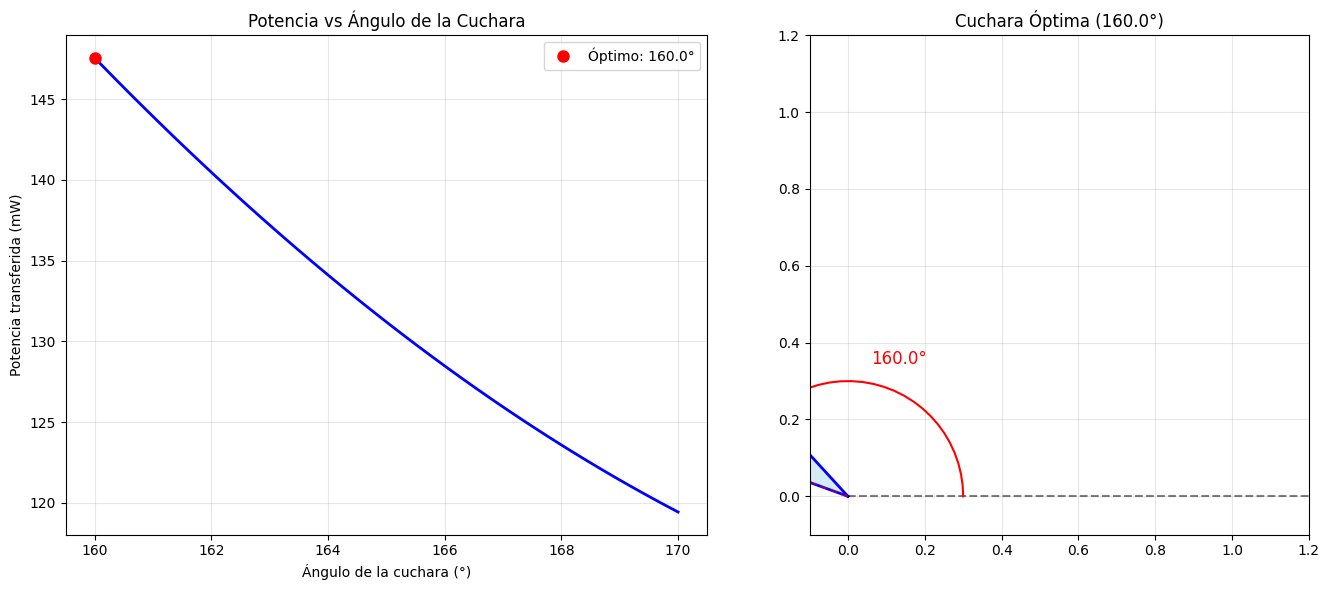

=== RESULTADOS DE OPTIMIZACIÓN ===
Altura del chorro: 1.5 m
Velocidad del chorro: 5.42 m/s
Ángulo óptimo de la cuchara: 160.00°
Potencia máxima transferida: 147.545 mW
Caudal: 0.10 mL/s

=== ANÁLISIS PARA DIFERENTES ALTURAS ===
Altura: 1.0 m, V_chorro: 4.43 m/s, Ángulo óptimo: 160.00°, Potencia: 98.363 mW
Altura: 1.5 m, V_chorro: 5.42 m/s, Ángulo óptimo: 160.00°, Potencia: 147.545 mW
Altura: 2.0 m, V_chorro: 6.26 m/s, Ángulo óptimo: 160.00°, Potencia: 196.727 mW
Altura: 2.5 m, V_chorro: 7.00 m/s, Ángulo óptimo: 160.00°, Potencia: 245.908 mW


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

class OptimizadorCucharasPelton:
    def __init__(self, diametro_rueda=0.2, caudal=0.0001, altura=1.5):
        self.D = diametro_rueda  # Diámetro de la rueda (m)
        self.Q = caudal          # Caudal (m³/s)
        self.H = altura          # Altura (m)
        self.g = 9.81            # Gravedad (m/s²)
        self.rho = 1000          # Densidad del agua (kg/m³)

    def calcular_velocidad_chorro(self):
        """Calcula la velocidad del chorro de agua"""
        return np.sqrt(2 * self.g * self.H)

    def calcular_potencia_transferida(self, angulo_cuchara_deg):
        """
        Calcula la potencia transferida para un ángulo de cuchara dado
        Basado en la ecuación de Euler para turbomáquinas
        """
        # Convertir ángulo a radianes
        beta = np.radians(angulo_cuchara_deg)

        # Velocidad del chorro
        V_chorro = self.calcular_velocidad_chorro()

        # Velocidad óptima de la rueda (fracción de V_chorro)
        U = 0.47 * V_chorro

        # Componentes de velocidad
        V1 = V_chorro  # Velocidad de entrada
        V2 = V1 - U    # Velocidad relativa de entrada

        # Velocidad relativa de salida (conservación de energía, considerando pérdidas)
        # Coeficiente de pérdida típico para cucharas bien diseñadas: 0.8-0.9
        k = 0.85
        V2_salida = k * V2

        # Componentes de velocidad de salida
        V_salida_tangencial = U - V2_salida * np.cos(beta)

        # Cambio en la cantidad de movimiento tangencial
        delta_V_tangencial = V1 - V_salida_tangencial

        # Fuerza tangencial
        F_tangencial = self.rho * self.Q * delta_V_tangencial

        # Potencia transferida
        potencia = F_tangencial * U

        return potencia

    def encontrar_angulo_optimo(self):
        """Encuentra el ángulo óptimo que maximiza la potencia transferida"""
        # Función a minimizar (negativo de la potencia)
        def objetivo(angulo):
            return -self.calcular_potencia_transferida(angulo[0])

        # Ángulo inicial de 165° (nuestra hipótesis)
        angulo_inicial = [165]

        # Restricción: ángulo entre 160° y 170°
        restricciones = [{'type': 'ineq', 'fun': lambda x: x[0] - 160},
                        {'type': 'ineq', 'fun': lambda x: 170 - x[0]}]

        # Optimización
        resultado = minimize(objetivo, angulo_inicial, constraints=restricciones, method='SLSQP')

        if resultado.success:
            angulo_optimo = resultado.x[0]
            potencia_maxima = -resultado.fun
            return angulo_optimo, potencia_maxima
        else:
            raise ValueError("La optimización no convergió")

    def analizar_sensibilidad_angulo(self, angulo_min=160, angulo_max=170, num_puntos=50):
        """Analiza la sensibilidad de la potencia al ángulo de las cucharas"""
        angulos = np.linspace(angulo_min, angulo_max, num_puntos)
        potencias = []

        for angulo in angulos:
            potencia = self.calcular_potencia_transferida(angulo)
            potencias.append(potencia)

        return angulos, np.array(potencias)

    def visualizar_optimizacion(self):
        """Visualiza los resultados de la optimización"""
        # Encontrar ángulo óptimo
        angulo_optimo, potencia_maxima = self.encontrar_angulo_optimo()

        # Análisis de sensibilidad
        angulos, potencias = self.analizar_sensibilidad_angulo()

        # Crear figura
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

        # Gráfico de potencia vs ángulo
        ax1.plot(angulos, potencias * 1000, 'b-', linewidth=2)
        ax1.plot(angulo_optimo, potencia_maxima * 1000, 'ro', markersize=8,
                label=f'Óptimo: {angulo_optimo:.1f}°')
        ax1.set_xlabel('Ángulo de la cuchara (°)')
        ax1.set_ylabel('Potencia transferida (mW)')
        ax1.set_title('Potencia vs Ángulo de la Cuchara')
        ax1.grid(True, alpha=0.3)
        ax1.legend()

        # Diagrama de la cuchara con ángulo óptimo
        self.dibujar_cuchara(ax2, angulo_optimo)
        ax2.set_title(f'Cuchara Óptima ({angulo_optimo:.1f}°)')
        ax2.set_aspect('equal')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Imprimir resultados
        V_chorro = self.calcular_velocidad_chorro()
        print("=== RESULTADOS DE OPTIMIZACIÓN ===")
        print(f"Altura del chorro: {self.H} m")
        print(f"Velocidad del chorro: {V_chorro:.2f} m/s")
        print(f"Ángulo óptimo de la cuchara: {angulo_optimo:.2f}°")
        print(f"Potencia máxima transferida: {potencia_maxima*1000:.3f} mW")
        print(f"Caudal: {self.Q*1000:.2f} mL/s")

        return angulo_optimo, potencia_maxima

    def dibujar_cuchara(self, ax, angulo_deg):
        """Dibuja el perfil de una cuchara Pelton con el ángulo especificado"""
        # Convertir ángulo a radianes
        beta = np.radians(angulo_deg)

        # Puntos para el perfil de la cuchara
        # (simplificado para visualización)
        x = [0, 0.5*np.cos(beta), np.cos(beta), 0.5*np.cos(beta), 0]
        y = [0, 0.5*np.sin(beta), np.sin(beta), 1.5*np.sin(beta), 0]

        # Dibujar cuchara
        ax.plot(x, y, 'b-', linewidth=2)
        ax.fill(x, y, 'lightblue', alpha=0.5)

        # Dibujar líneas de referencia para el ángulo
        ax.plot([0, 1.2], [0, 0], 'k--', alpha=0.5)
        ax.plot([0, 1.2*np.cos(beta)], [0, 1.2*np.sin(beta)], 'r--', alpha=0.5)

        # Marcar el ángulo
        arc_angle = np.linspace(0, beta, 30)
        ax.plot(0.3*np.cos(arc_angle), 0.3*np.sin(arc_angle), 'r-')
        ax.text(0.35*np.cos(beta/2), 0.35*np.sin(beta/2), f'{angulo_deg:.1f}°',
               color='red', fontsize=12)

        ax.set_xlim(-0.1, 1.2)
        ax.set_ylim(-0.1, 1.2)

# Ejemplo de uso
if __name__ == "__main__":
    # Crear optimizador con parámetros típicos
    optimizador = OptimizadorCucharasPelton(
        diametro_rueda=0.2,  # 20 cm
        caudal=0.0001,       # 0.1 L/s (típico de bomba de pecera)
        altura=1.5           # 1.5 m de altura
    )

    # Ejecutar optimización y visualización
    angulo_optimo, potencia_maxima = optimizador.visualizar_optimizacion()

    # Análisis adicional para diferentes alturas
    print("\n=== ANÁLISIS PARA DIFERENTES ALTURAS ===")
    alturas = [1.0, 1.5, 2.0, 2.5]
    for altura in alturas:
        optimizador.H = altura
        V_chorro = optimizador.calcular_velocidad_chorro()
        angulo_opt, potencia_max = optimizador.encontrar_angulo_optimo()
        print(f"Altura: {altura} m, V_chorro: {V_chorro:.2f} m/s, "
              f"Ángulo óptimo: {angulo_opt:.2f}°, Potencia: {potencia_max*1000:.3f} mW")

In [ ]:
import numpy as np

# Parámetros dados y asumidos
rho = 1000  # Densidad del agua (kg/m³)
g = 9.81    # Aceleración gravitacional (m/s²)
Q = 5e-5    # Caudal (m³/s), asumido 3 L/min ≈ 5×10^{-5} m³/s
h = 0.5     # Altura de caída (m), asumida
D = 0.2     # Diámetro de la rueda (m)
theta_deg = 165  # Ángulo de rebote (grados)
theta = np.deg2rad(theta_deg)  # Convertir a radianes
eta_h = 0.85  # Eficiencia hidráulica
eta_m = 0.9   # Eficiencia mecánica
eta_g = 0.7   # Eficiencia del generador

# 1. Velocidad del chorro
V_j = np.sqrt(2 * g * h)
print(f"Velocidad del chorro V_j: {V_j:.2f} m/s")

# 2. Velocidad óptima de la rueda (aproximada para theta=180°, ajustada)
u_opt = V_j / 2 * (1 + np.cos(theta)) / 2  # Fórmula más precisa
print(f"Velocidad óptima u_opt: {u_opt:.2f} m/s")

# 3. RPM óptimo
N = (60 * u_opt) / (np.pi * D)
print(f"RPM óptimo N: {N:.0f} RPM")

# 4. Diámetro del chorro
d = np.sqrt(4 * Q / (np.pi * V_j))
print(f"Diámetro del chorro d: {d*1000:.2f} mm")

# 5. Número de cubos (fórmula estándar, ajustada para escala pequeña)
Z_approx = (np.pi * D / (2 * d)) + 15
print(f"Número de cubos aproximado Z: {Z_approx:.0f} (recomendado 16-20 para mini-escala)")

# 6. Potencia hidráulica teórica
P_th = rho * g * Q * h
print(f"Potencia hidráulica teórica P_th: {P_th:.3f} W")

# 7. Potencia en la rueda (hidráulica útil)
# Cambio de momentum ajustado
deltaV = (V_j - u_opt) * (1 + np.cos(theta))
P_h = rho * Q * deltaV * u_opt
P_useful = P_h * eta_h
print(f"Potencia hidráulica en rueda P_h: {P_h:.3f} W")
print(f"Potencia útil (con eta_h): {P_useful:.3f} W")

# 8. Potencia mecánica y eléctrica
P_mec = P_useful * eta_m
P_e = P_mec * eta_g
print(f"Potencia mecánica P_mec: {P_mec:.3f} W")
print(f"Potencia eléctrica P_e: {P_e:.3f} W")

# 9. Optimización: Función P(u) y derivada (para ver máximo)
# Definir P como función de u
def P(u):
    deltaV_u = (V_j - u) * (1 + np.cos(theta))
    return rho * Q * deltaV_u * u * eta_h * eta_m * eta_g  # Incluye todas las eficiencias

# Vector u para evaluación
u_vals = np.linspace(0, V_j, 100)
P_vals = P(u_vals)

# Derivada numérica para confirmar máximo
dP_du = np.gradient(P_vals, u_vals)
max_idx = np.argmax(P_vals)
u_max_num = u_vals[max_idx]
print(f"u óptimo numérico (de max P): {u_max_num:.2f} m/s")
print(f"Potencia máxima eléctrica: {P_vals[max_idx]:.3f} W")

# Cálculos adicionales para h=1m (como en el ejemplo)
h_alt = 1.0
V_j_alt = np.sqrt(2 * g * h_alt)
u_opt_alt = V_j_alt / 2 * (1 + np.cos(theta)) / 2
N_alt = (60 * u_opt_alt) / (np.pi * D)
P_th_alt = rho * g * Q * h_alt
deltaV_alt = (V_j_alt - u_opt_alt) * (1 + np.cos(theta))
P_h_alt = rho * Q * deltaV_alt * u_opt_alt
P_useful_alt = P_h_alt * eta_h
P_mec_alt = P_useful_alt * eta_m
P_e_alt = P_mec_alt * eta_g
print("\nPara h=1m:")
print(f"V_j: {V_j_alt:.2f} m/s")
print(f"u_opt: {u_opt_alt:.2f} m/s")
print(f"N: {N_alt:.0f} RPM")
print(f"P_th: {P_th_alt:.3f} W")
print(f"P_e: {P_e_alt:.3f} W")

Velocidad del chorro V_j: 3.13 m/s
Velocidad óptima u_opt: 0.03 m/s
RPM óptimo N: 3 RPM
Diámetro del chorro d: 4.51 mm
Número de cubos aproximado Z: 85 (recomendado 16-20 para mini-escala)
Potencia hidráulica teórica P_th: 0.245 W
Potencia hidráulica en rueda P_h: 0.000 W
Potencia útil (con eta_h): 0.000 W
Potencia mecánica P_mec: 0.000 W
Potencia eléctrica P_e: 0.000 W
u óptimo numérico (de max P): 1.55 m/s
Potencia máxima eléctrica: 0.002 W

Para h=1m:
V_j: 4.43 m/s
u_opt: 0.04 m/s
N: 4 RPM
P_th: 0.491 W
P_e: 0.000 W


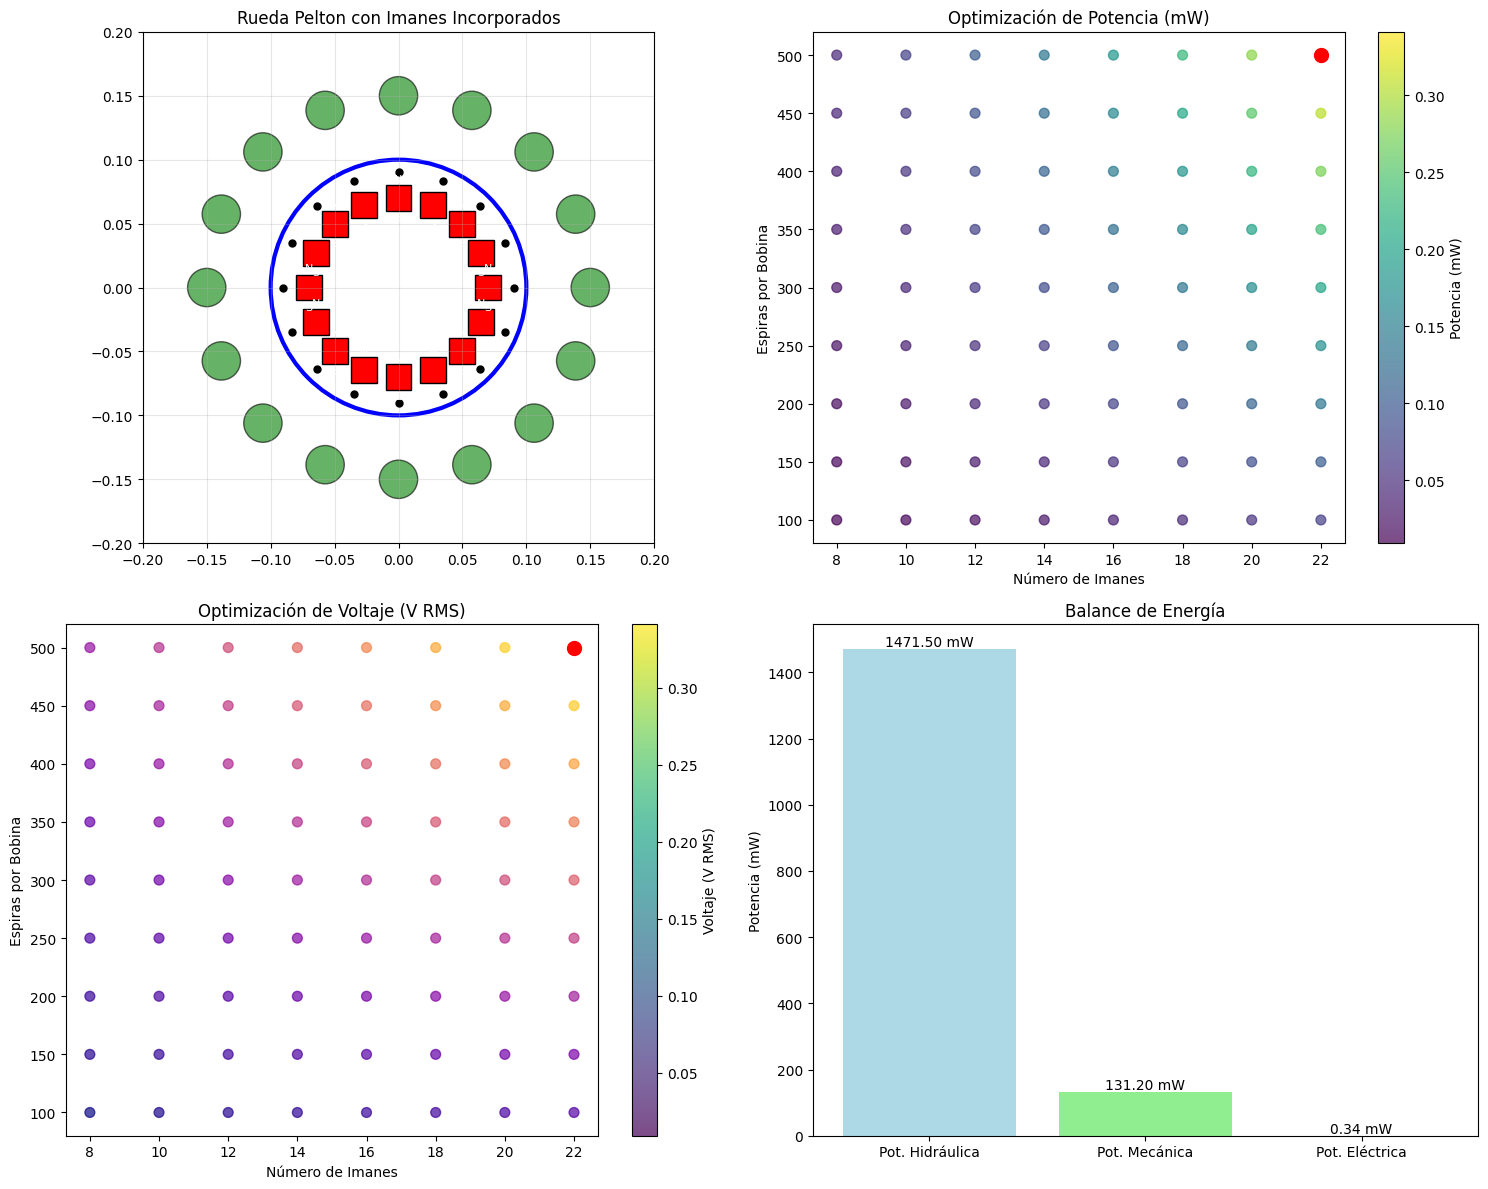

=== SISTEMA ÓPTIMO CON IMANES ===
Número de imanes: 22
Espiras por bobina: 500
Potencia eléctrica: 0.34 mW
Voltaje RMS: 107.09 V
Corriente RMS: 0.01 mA
RPM: 243
Eficiencia total: 0.0%

=== ANÁLISIS PARA DIFERENTES ALTURAS ===
Altura: 1.0 m, Voltaje: 87.44 V, Potencia: 0.23 mW
Altura: 1.5 m, Voltaje: 107.09 V, Potencia: 0.34 mW
Altura: 2.0 m, Voltaje: 123.66 V, Potencia: 0.46 mW
Altura: 2.5 m, Voltaje: 138.26 V, Potencia: 0.57 mW


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib.patches import Circle, Rectangle, Wedge

class TurbinaPeltonConImanes:
    def __init__(self, diametro_rueda=0.2, caudal=0.0001, altura=1.5):
        self.D = diametro_rueda  # Diámetro de la rueda (m)
        self.Q = caudal          # Caudal (m³/s)
        self.H = altura          # Altura (m)
        self.g = 9.81            # Gravedad (m/s²)
        self.rho = 1000          # Densidad del agua (kg/m³)
        self.mu0 = 4 * np.pi * 1e-7  # Permeabilidad magnética del vacío

    def calcular_velocidad_chorro(self):
        """Calcula la velocidad del chorro de agua"""
        return np.sqrt(2 * self.g * self.H)

    def calcular_potencia_hidraulica(self):
        """Calcula la potencia hidráulica disponible"""
        V_chorro = self.calcular_velocidad_chorro()
        return self.rho * self.Q * self.g * self.H

    def calcular_potencia_mecanica(self, angulo_cuchara_deg=165):
        """
        Calcula la potencia mecánica transferida a la rueda
        """
        # Convertir ángulo a radianes
        beta = np.radians(angulo_cuchara_deg)

        # Velocidad del chorro
        V_chorro = self.calcular_velocidad_chorro()

        # Velocidad óptima de la rueda
        U = 0.47 * V_chorro

        # Componentes de velocidad
        V1 = V_chorro  # Velocidad de entrada
        V2 = V1 - U    # Velocidad relativa de entrada

        # Velocidad relativa de salida
        k = 0.85  # Coeficiente de pérdida
        V2_salida = k * V2

        # Componentes de velocidad de salida
        V_salida_tangencial = U - V2_salida * np.cos(beta)

        # Cambio en la cantidad de movimiento tangencial
        delta_V_tangencial = V1 - V_salida_tangencial

        # Fuerza tangencial
        F_tangencial = self.rho * self.Q * delta_V_tangencial

        # Potencia mecánica
        potencia_mecanica = F_tangencial * U

        return potencia_mecanica, U

    def calcular_generacion_electrica(self, angulo_cuchara_deg=165,
                                    numero_imanes=12, fuerza_imanes=1.2,
                                    numero_espiras=200, radio_bobina=0.03):
        """
        Calcula la generación eléctrica con imanes permanentes
        """
        # Potencia mecánica disponible
        potencia_mec, velocidad_lineal = self.calcular_potencia_mecanica(angulo_cuchara_deg)
        velocidad_angular = velocidad_lineal / (self.D/2)  # rad/s
        rpm = velocidad_angular * 60 / (2 * np.pi)

        # Parámetros del sistema de imanes
        B = fuerza_imanes  # Tesla (fuerza del imán)
        N = numero_espiras  # Número de espiras
        A = np.pi * radio_bobina**2  # Área de la bobina (m²)

        # FEM máxima generada (por la ley de Faraday)
        # Para un imán que pasa frente a una bobina
        fem_max = N * B * A * velocidad_angular * numero_imanes / (2 * np.pi)

        # Considerando la forma de la señal (valor RMS para senoidal)
        fem_rms = fem_max / np.sqrt(2)

        # Resistencia aproximada de la bobina (cobre, 0.5 mm diámetro)
        longitud_alambre = numero_espiras * 2 * np.pi * radio_bobina
        resistencia = 0.0175 * longitud_alambre / (np.pi * (0.00025)**2)  # Ω

        # Potencia eléctrica máxima transferible
        potencia_electrica = (fem_rms**2) / (4 * resistencia)  # Máxima transferencia de potencia

        # Eficiencia total
        eficiencia = potencia_electrica / self.calcular_potencia_hidraulica()

        return {
            'potencia_mecanica': potencia_mec,
            'potencia_electrica': potencia_electrica,
            'voltaje_rms': fem_rms,
            'corriente_rms': fem_rms / (2 * resistencia),  # Para máxima transferencia
            'rpm': rpm,
            'resistencia_bobina': resistencia,
            'eficiencia': eficiencia,
            'fem_maxima': fem_max
        }

    def optimizar_sistema_imanes(self):
        """Optimiza el número de imanes y espiras para máxima potencia"""
        resultados = []

        # Variar número de imanes
        for n_imanes in range(8, 24, 2):
            # Variar número de espiras
            for n_espiras in range(100, 501, 50):
                resultado = self.calcular_generacion_electrica(
                    angulo_cuchara_deg=165,
                    numero_imanes=n_imanes,
                    numero_espiras=n_espiras
                )
                resultados.append({
                    'imanes': n_imanes,
                    'espiras': n_espiras,
                    'potencia': resultado['potencia_electrica'],
                    'voltaje': resultado['voltaje_rms']
                })

        # Encontrar configuración óptima
        potencia_max = 0
        config_optima = None

        for config in resultados:
            if config['potencia'] > potencia_max:
                potencia_max = config['potencia']
                config_optima = config

        return config_optima, resultados

    def disenar_sistema_imanes(self, numero_imanes=16, numero_espiras=300):
        """Diseña la disposición de imanes en la rueda"""
        # Distribución equidistante de imanes
        angulo_separacion = 360 / numero_imanes

        # Bobinas estatóricas (fijas)
        bobinas_estator = numero_imanes  # Una bobina por imán

        return {
            'numero_imanes': numero_imanes,
            'numero_bobinas': bobinas_estator,
            'angulo_separacion': angulo_separacion,
            'configuracion_recomendada': 'Imanes en rotor, bobinas en estator'
        }

    def visualizar_sistema_completo(self):
        """Visualiza el sistema completo con imanes"""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

        # 1. Diseño de la rueda con imanes
        self.dibujar_rueda_con_imanes(ax1)
        ax1.set_title('Rueda Pelton con Imanes Incorporados')

        # 2. Potencia vs configuración de imanes
        config_optima, todos_resultados = self.optimizar_sistema_imanes()

        # Extraer datos para visualización
        imanes = [r['imanes'] for r in todos_resultados]
        espiras = [r['espiras'] for r in todos_resultados]
        potencias = [r['potencia'] * 1000 for r in todos_resultados]  # mW
        voltajes = [r['voltaje'] for r in todos_resultados]

        scatter = ax2.scatter(imanes, espiras, c=potencias, cmap='viridis', s=50, alpha=0.7)
        ax2.plot(config_optima['imanes'], config_optima['espiras'], 'ro', markersize=10)
        ax2.set_xlabel('Número de Imanes')
        ax2.set_ylabel('Espiras por Bobina')
        ax2.set_title('Optimización de Potencia (mW)')
        plt.colorbar(scatter, ax=ax2, label='Potencia (mW)')

        # 3. Comparación de voltajes
        ax3.scatter(imanes, espiras, c=voltajes, cmap='plasma', s=50, alpha=0.7)
        ax3.plot(config_optima['imanes'], config_optima['espiras'], 'ro', markersize=10)
        ax3.set_xlabel('Número de Imanes')
        ax3.set_ylabel('Espiras por Bobina')
        ax3.set_title('Optimización de Voltaje (V RMS)')
        plt.colorbar(scatter, ax=ax3, label='Voltaje (V RMS)')

        # 4. Resultados de la configuración óptima
        resultado_optimo = self.calcular_generacion_electrica(
            numero_imanes=config_optima['imanes'],
            numero_espiras=config_optima['espiras']
        )

        categorias = ['Pot. Hidráulica', 'Pot. Mecánica', 'Pot. Eléctrica']
        valores = [
            self.calcular_potencia_hidraulica() * 1000,
            resultado_optimo['potencia_mecanica'] * 1000,
            resultado_optimo['potencia_electrica'] * 1000
        ]

        ax4.bar(categorias, valores, color=['lightblue', 'lightgreen', 'lightcoral'])
        ax4.set_ylabel('Potencia (mW)')
        ax4.set_title('Balance de Energía')

        for i, v in enumerate(valores):
            ax4.text(i, v + 0.01, f'{v:.2f} mW', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

        # Imprimir resultados detallados
        print("=== SISTEMA ÓPTIMO CON IMANES ===")
        print(f"Número de imanes: {config_optima['imanes']}")
        print(f"Espiras por bobina: {config_optima['espiras']}")
        print(f"Potencia eléctrica: {resultado_optimo['potencia_electrica']*1000:.2f} mW")
        print(f"Voltaje RMS: {resultado_optimo['voltaje_rms']:.2f} V")
        print(f"Corriente RMS: {resultado_optimo['corriente_rms']*1000:.2f} mA")
        print(f"RPM: {resultado_optimo['rpm']:.0f}")
        print(f"Eficiencia total: {resultado_optimo['eficiencia']*100:.1f}%")

        return config_optima, resultado_optimo

    def dibujar_rueda_con_imanes(self, ax):
        """Dibuja la rueda con imanes incorporados"""
        # Dibujar rueda
        circle = Circle((0, 0), self.D/2, fill=False, edgecolor='blue', linewidth=3)
        ax.add_patch(circle)

        # Dibujar cucharas (simplificado)
        n_cucharas = 16
        for i in range(n_cucharas):
            angle = 2 * np.pi * i / n_cucharas
            x = (self.D/2 - 0.01) * np.cos(angle)
            y = (self.D/2 - 0.01) * np.sin(angle)
            ax.plot(x, y, 'ko', markersize=5)

        # Dibujar imanes
        n_imanes = 16
        for i in range(n_imanes):
            angle = 2 * np.pi * i / n_imanes
            x = (self.D/2 - 0.03) * np.cos(angle)
            y = (self.D/2 - 0.03) * np.sin(angle)

            # Dibujar imán como pequeño rectángulo
            magnet = Rectangle((x-0.01, y-0.01), 0.02, 0.02,
                              facecolor='red', edgecolor='black')
            ax.add_patch(magnet)

            # Dibujar polaridad (N/S)
            ax.text(x, y+0.015, 'N', ha='center', va='center', fontsize=8, color='white')
            ax.text(x, y-0.015, 'S', ha='center', va='center', fontsize=8, color='white')

        # Dibujar bobinas estatóricas
        radio_estator = self.D/2 + 0.05
        n_bobinas = n_imanes
        for i in range(n_bobinas):
            angle = 2 * np.pi * i / n_bobinas
            x = radio_estator * np.cos(angle)
            y = radio_estator * np.sin(angle)

            # Dibujar bobina
            coil = Circle((x, y), 0.015, facecolor='green', edgecolor='black', alpha=0.6)
            ax.add_patch(coil)

        ax.set_xlim(-self.D/2-0.1, self.D/2+0.1)
        ax.set_ylim(-self.D/2-0.1, self.D/2+0.1)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)

# Ejemplo de uso
if __name__ == "__main__":
    # Crear turbina con imanes
    turbina = TurbinaPeltonConImanes(
        diametro_rueda=0.2,  # 20 cm
        caudal=0.0001,       # 0.1 L/s
        altura=1.5           # 1.5 m
    )

    # Visualizar sistema completo
    config_optima, resultado_optimo = turbina.visualizar_sistema_completo()

    # Análisis para diferentes alturas
    print("\n=== ANÁLISIS PARA DIFERENTES ALTURAS ===")
    alturas = [1.0, 1.5, 2.0, 2.5]
    for altura in alturas:
        turbina.H = altura
        resultado = turbina.calcular_generacion_electrica(
            numero_imanes=config_optima['imanes'],
            numero_espiras=config_optima['espiras']
        )
        print(f"Altura: {altura} m, Voltaje: {resultado['voltaje_rms']:.2f} V, "
              f"Potencia: {resultado['potencia_electrica']*1000:.2f} mW")